In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [2]:
import os
import sys
import HeST as hest
# import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle
import scipy
import glob
import pandas

plt.rcParams.update({'font.size': 14})

In [ ]:
plot_hist_flavors(slurm_practice)

In [6]:
bin1 = np.array([0])
bin2 = np.linspace(0, .50, 5)
bin3 = np.linspace(0, .50, 5)
bin4 = np.array([0])
bin5 = np.linspace(0, .50, 2)
bin6 = np.array([0])
refl_eff = np.linspace(0.15, .450, 3)
bin1, bin2, bin3, bin4, bin5, bin6, refl_eff = np.meshgrid(bin1, bin2, bin3, bin4, bin5, bin6, refl_eff)

combinations = np.round(np.column_stack((
    bin1.ravel(),
    bin2.ravel(),
    bin3.ravel(),
    bin4.ravel(),
    bin5.ravel(),
    bin6.ravel(),
    refl_eff.ravel()
)), 3)

In [7]:
print(np.shape(combinations))
print((combinations))

(150, 7)
[[0.   0.   0.   ... 0.   0.   0.15]
 [0.   0.   0.   ... 0.   0.   0.3 ]
 [0.   0.   0.   ... 0.   0.   0.45]
 ...
 [0.   0.5  0.5  ... 0.5  0.   0.15]
 [0.   0.5  0.5  ... 0.5  0.   0.3 ]
 [0.   0.5  0.5  ... 0.5  0.   0.45]]


In [3]:
geometries = []
coordinates = []
x = [0, 1.145, -1.145]
y = [1.75, -1.322, -1.322]
geometry_height = [2,2,2,4,4,4,5,6,6,6]
fnames = []
directory = '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/geometry_sweep_3/'
for i in range(10):
    h = geometry_height[i]
    heights = [0.5, h/2, h - 0.5]
    for j in range(3):
        geometries.append(i)
        coordinates.append([x[j], y[j], heights[j]])
        fnames.append(directory + f'setup_{i}_pos_{x[j]}_{y[j]}_{heights[j]}.pkl')
        

print(np.shape(geometries))
print(np.shape(coordinates))
print(np.shape(fnames))

everything = np.column_stack((fnames, geometries, coordinates))

with open(os.path.join('parameters', 'detector_geometry_sweep_3.txt'), 'a+') as f:
    for i, column in enumerate(everything):
        f.write(column[0])
        f.write(' ')
        f.write(f'{column[1]}')
        f.write(' ')
        f.write(f'{column[2]},{column[3]},{column[4]},')
        f.write('\n')


(30,)
(30, 3)
(30,)


In [ ]:
# write a file name 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script


with open(os.path.join('parameters', 'further_zoom.txt'), 'a+') as f:
    for i, (bin1, bin2, bin3, bin4, bin5, bin6, refl_eff) in enumerate(combinations):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_{i}.pkl')
        f.write(' ')
        f.write(f'{refl_eff}')
        f.write(' ')
        f.write(f'{bin1},')
        f.write(f'{bin2},')
        f.write(f'{bin3},')
        f.write(f'{bin4},')
        f.write(f'{bin5},')
        f.write(f'{bin6},')
        f.write('\n')


NameError: name 'combinations' is not defined

In [10]:
# so we want the position to change, and that is it. 
# lets do 
x = np.linspace(0, 3.4, 9)
y = 0
z = [4]

xx, yy, zz = np.meshgrid(x, y, z)
combinations = np.column_stack((xx.ravel(), yy.ravel(), zz.ravel()))
print(combinations)

[[0.    0.    4.   ]
 [0.425 0.    4.   ]
 [0.85  0.    4.   ]
 [1.275 0.    4.   ]
 [1.7   0.    4.   ]
 [2.125 0.    4.   ]
 [2.55  0.    4.   ]
 [2.975 0.    4.   ]
 [3.4   0.    4.   ]]


In [11]:
# write a file name 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script


with open(os.path.join('parameters', 'centroid_understanding_z_4.0.txt'), 'a+') as f:
    for i, (x, y, z) in enumerate(combinations):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/analyzing_resolution/line_step/z_4.0/trial_{i}.pkl')
        f.write(' ')
        f.write(f'{x},{y},{z},')
        f.write(' ')
        f.write('\n')

In [3]:
# we want to be able to package in a bunch of positions. 
x = np.array([0, 2.9])
y = np.array([0])
z = np.array([0.05, 1.75, 3.5])

xx, yy, zz = np.meshgrid(x,y,z)

combined = np.column_stack((xx.flatten(),yy.flatten(),zz.flatten()))
print(combined)

[[0.   0.   0.05]
 [0.   0.   1.75]
 [0.   0.   3.5 ]
 [2.9  0.   0.05]
 [2.9  0.   1.75]
 [2.9  0.   3.5 ]]


In [5]:
# write a file name 
import time 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script
name_directory =os.path.join('', time.strftime('%y%m%d', time.gmtime()))

import numpy as np

with open(os.path.join('parameters', 'big_volume_pos_sweep.txt'), 'a+') as f:
    for i, row in enumerate(combined):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/trial_{i}.pkl')
        f.write(' ')
        for item in row:
            f.write(str(item))
            f.write(',')
        f.write('\n')


[0.   0.   0.05]


In [ ]:
# write a file name 
import time 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script
name_directory =os.path.join('', time.strftime('%y%m%d', time.gmtime()))

import numpy as np
num_quasiparticles = np.random.randint(low = 800000, high= int(3e6), size=1000)

with open(os.path.join('parameters', 'runs_1000_with_points.txt'), 'a+') as f:
    for i, nqps in enumerate(num_quasiparticles):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/ch1_ch2_comparison/possible_params/trial_{i}.pkl')
        f.write(' ')
        f.write(str(nqps))
        f.write('\n')


In [ ]:
# the goal of this is to sweep through the files, collect the channel sums, and then move save that and move on. 
import glob
file_list = glob.glob('./data/sample_1000/*')

channel_1 = np.empty(len(file_list))
channel_2 = np.empty(len(file_list))
for i, file in enumerate(file_list):
    with open(file, 'rb') as f:
        evap = pickle.load(f)
        channel_1[i] = len(evap.arrivalTimes_us[0])
        channel_2[i] = len(evap.arrivalTimes_us[1])
np.savetxt('./data/ch1_ch2_comparison/sample_run_data.txt', np.column_stack((channel_1, channel_2)))
config = {}
config['diff_prob'] = 0.8
config['refl_prob'] = 0.3
config['evap_eff'] = 0.6
config['num_qps'] = 10000
with open("config.txt", "w+") as file:
    for key, value in config.items():
        file.write(f"{key}={value}\n")

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(channel_1, channel_2)
ax.set_aspect('equal',adjustable= 'box')
ax.set_xlim(0, 8000)
ax.set_ylim(0, 8000)

In [17]:
9375 * 0.4e-6

0.00375

(4, 9375)


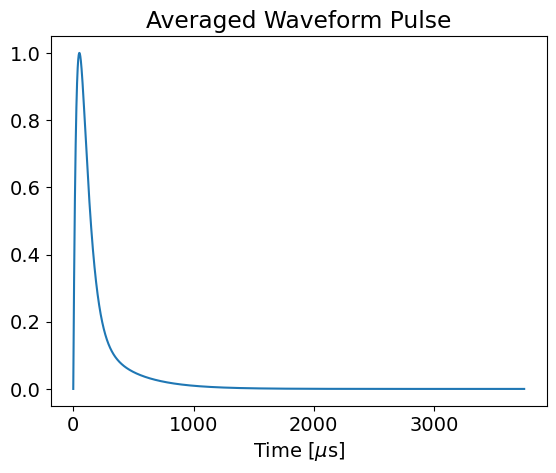

In [ ]:
templates = np.load('./data/dispersion_curves/shortened_template.npy')
print(np.shape(templates))
time = np.linspace(0, 3.75,9375 )* 1e3
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time, cpd1_scint_template)
ax.set_xlabel(r'Time [$\mu$s]')

# ax.plot(time, cpd2_scint_template, label = 'cpd2 scint')
# ax.plot(time, cpd1_evap_template, label = 'cpd1 evap')
# ax.plot(time, cpd2_evap_template, label = 'cpd2 evap')
ax.set_title('Averaged Scintillation Pulse')
# ax.set_xlim(0, 1.5)
fig.savefig('./data/plots/Template_amp_normalized.png')

In [ ]:
# sampling rate is 1.25e6 per second: meaning that per each thing has 1/1.25e6 --> 0.8e-6 still the same as before. 
# now we need to save 
upper = int(5 * 2500)
lower = int(1.25*2500)
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time[lower:upper], cpd1_scint_template[lower:upper], label= 'cpd1 scint')
ax.plot(time[lower:upper], cpd2_scint_template[lower:upper], label = 'cpd2 scint')
ax.plot(time[lower:upper], cpd1_evap_template[lower:upper], label = 'cpd1 evap')
ax.plot(time[lower:upper], cpd2_evap_template[lower:upper], label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
print(time[-3] - time[-4])

 # this should be in us I think... 

In [ ]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5_test.pkl', 'rb') as f:
    many_qps = pickle.load(f)
plot_hist_flavors(many_qps)
plot_stacked_hist(many_qps)
plot_waveform(many_qps)

In [ ]:
time = np.arange(0, 9999 * 0.8e-6, 0.8e-6)

In [ ]:
cpd1_hits = np.histogram(many_qps.arrivalTimes_us[0], bins=3750, range = [0,3000])[0] * 10e-3
cpd2_hits = np.histogram(many_qps.arrivalTimes_us[1], bins=3750, range = [0,3000])[0] * 10e-3
plt.plot(time, np.convolve(cpd1_hits, cpd1_template))

plt.xlabel('Seconds')
plt.ylabel('Energy')
plt.title('CPD 1 pulse comparison')

In [ ]:
s1, s2, time = generate_waveform(many_qps)
plt.plot(time, s1)

In [ ]:
plt.hist(many_qps.arrivalTimes_us[0], bins=200, range = [0,3000])

In [ ]:
# I want to read these in by height, and then I can move from there
h_10_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_*.pkl')
h_15_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_*.pkl')
h_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_5_*.pkl')
h_2_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_2.5_*.pkl')
print(h_15_files)

In [ ]:
extract_pulse(h_15_files[:3])

In [ ]:
extract_pulse(['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test_2.pkl'])

In [ ]:
hex_colors = [
    "#FF5733", "#33FF57", "#3357FF", "#FF33A1", "#000000",
    "#33FFFF", "#A133FF", "#FF8C33", "#57FF33", "#FF3333",
    "#1E90FF", "#FFD700"  # Added Dodger Blue and Gold
]

markers = ["o", "s", "^", "v", "D", "X", "P", "*", "H", "<"]

all_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h*.pkl')
names = []
waveforms = []
fig, ax = plt.subplots(figsize=(16, 8))
for ii, f in enumerate(all_files):
    print(f)
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    name = f.split('/')[-1][:-4]
    names.append(name)
    s1, s2, time = generate_waveform(evap)
    waveforms.append([s1, s2])
    ax.scatter(time, s1, color=hex_colors[ii],s=10 ,label=name + ' CPD1',  alpha=0.1 ) 
    # ax.plot(time, s1, label=name + ' CPD2') 


ax.legend()

    
    


In [ ]:
fig, ax = plt.subplots()
ax.plot(time[lower:upper] - 0.001, 88 * cpd1_evap_template[lower:upper] / 1921619327.2159166, label = 'cpd1 evap')

In [ ]:
file = all_files[0]
print(file.split('/'))
name = file.split('/')[-1]
print(name[:-4])

In [ ]:
# for each, I want to store the cpd time arrays, so we need a 3D thing

def extract_pulse(file_list):
    heights = []
    for ii, file in enumerate(file_list):
        with open(file, 'rb') as f:
            height = pickle.load(f)
        
        plot_stacked_hist(height, title=file_list[ii][-14:-4])
        plot_hist_flavors(height,title=file_list[ii][-14:-4] )
        cpd1 = height.arrivalTimes_us[0]
        cpd2 = height.arrivalTimes_us[1]
        heights.append(cpd1)
        heights.append(cpd2)
    return heights

h_15 = extract_pulse(h_15_files)

In [ ]:
plt.title(str(h_15_files[0])[-14:-4])
plt.hist(h_15[0], bins=200, range = (0,3000))

In [ ]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 0.01, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]

In [ ]:
0.01/25000

In [ ]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test.pkl', 'rb') as f:
    evap = pickle.load(f)
# plot_stacked_hist(evap)
# plot_hist_flavors(evap)
plot_waveform(evap)
plt.plot(time - 0.0011, 110 * cpd2_evap_template)

In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/*.pkl')
for ii, f in enumerate(file_list):
    if ii%2==0 or ii%5==0:
        continue
    print(f)
    title = f.split('/')[-1][:-4]
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    
    plot_hist_flavors(evap, title = title)
    if ii>50:
        break

In [ ]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_*.csv')

In [ ]:
import re

def extract_number(filename, prefix, delimiter):
    match = re.search(rf"{prefix}_(\d+)\.{delimiter}", filename)
    return int(match.group(1)) if match else None

# Create a dictionary mapping numbers to file paths
config_map = {extract_number(f, "config", 'csv'): f for f in config_list}
print(config_map)
trial_map = {extract_number(f, "trial", 'pkl'): f for f in trial_list}
print(trial_map)


# Match based on extracted numbers
matched_pairs = {num: (config_map.get(num), trial_map.get(num)) for num in set(config_map) & set(trial_map)}

for num, (config, trial) in matched_pairs.items():
    print(f"Config: {config} <--> Trial: {trial}")

In [ ]:
trial_map.get(3)

In [ ]:
extract_pulse(file_list=file_list[:3])

In [ ]:
fig, ax = plt.subplots()
with open(file_list[0], 'rb') as f:
    evap = pickle.load(f)
s1, s2, time =generate_waveform(evap)
ax.plot(time, s1, label='CPD1')
ax.plot(time, s2, label='CPD2')

In [4]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

least_squares = np.empty((len(config_list)))
fig, axs = plt.subplots(9, 9, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
i = 0
for num, (config, trial) in matched_pairs.items():
    with open(trial, 'rb') as file:
        evap = pickle.load(file)   
    config = pandas.read_csv(config)
    refl_prob = str(config['refl_prob'][0])
    evap_prob = str(config['evap_eff'][0])
    title =  'refl_prob ' + refl_prob + ' evap_prob ' + evap_prob
    s1, s2 , time =generate_waveform(evap)

    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak
    least_squares[i] = np.sum(s1**2 - new_template**2)
    ax[i].plot(time, new_template, label = 'CPD1 template')
    ax[i].plot(time, s1, label='CPD1')
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_title('refl_prob ' + refl_prob + ' evap_prob ' + evap_prob, fontsize=8)
    ax[i].legend(loc='upper right', fontsize=8)
    ax[i].grid()
    ax[i].set_xlim(0, 0.003)
    i += 1
fig.tight_layout()
fig.savefig('sweep_2d_refl_evap.png', dpi=300)


NameError: name 'config_list' is not defined

In [ ]:
plt.plot(least_squares)

In [ ]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_*.csv')
matched_pairs = get_file_map(config_list=config_list, trial_list=trial_list)

In [ ]:
extract_pulse(trial_list[0:3])

In [ ]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

least_squares = np.empty((len(config_list)))
fig, axs = plt.subplots(10, 10, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
i = 0
for num, (config, trial) in matched_pairs.items():
    with open(trial, 'rb') as file:
        evap = pickle.load(file)   
    config = pandas.read_csv(config)
    phonon = str(config['evap_eff'][0])
    rminus = str(config['evap_eff'][1])
    rplus = str(config['evap_eff'][2])
    title = 'p' + phonon +' rminus' + rminus + ' rplus' + rplus
    s1, s2 , time =generate_waveform(evap)

    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak
    least_squares[i] = np.sum(s1**2 - new_template**2)
    ax[i].plot(time, new_template + 1, label = 'CPD1 template')
    ax[i].plot(time, s1, label='CPD1')
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_title(title, fontsize=6)
    ax[i].legend(loc='upper right', fontsize=6)
    ax[i].grid()
    ax[i].set_xlim(0, 0.003)
    i += 1
fig.tight_layout()

In [ ]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[0]


plt.plot(template_1)
plt.plot(template_2)

In [ ]:
def formulate_template(s1, template_1):
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak
    return new_template

In [ ]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

least_squares = np.empty((len(config_list)))
fig, axs = plt.subplots(10, 10, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
i = 0
for num, (config, trial) in matched_pairs.items():
    print(num)
    if num == 1:
        continue
    with open(trial, 'rb') as file:
        evap = pickle.load(file)   
    config = pandas.read_csv(config)
    phonon = str(config['evap_eff'][0])
    rminus = str(config['evap_eff'][1])
    rplus = str(config['evap_eff'][2])
    title = 'p' + phonon +' rminus' + rminus + ' rplus' + rplus
    s1, s2 , time =generate_waveform(evap)
    new_template = formulate_template(s1, template_1)

    fs = evap.flavor
    for value in np.unique(fs[0]):
        mask = (fs[0] == value)
        ax[i].hist(evap.arrivalTimes_us[0][mask], bins = 200, range = [0,3000], alpha= 0.7,stacked=True, label = value)


    ax[i].plot(time * 1e6, new_template + 1, label = 'CPD1 template')
    ax[i].set_title(title, fontsize=6)
    ax[i].legend(loc='upper right', fontsize=6)
    ax[i].grid()
    ax[i].set_xlim(0, 3000)
    i += 1
    if i > 99:
        break
fig.tight_layout()
fig.savefig('flavor_breakdown_mom_sweep.png', dpi=300)

In [ ]:
plt.plot(least_squares)
plt.ylim(1e5, 2e6)
plt.xlim(0, 100)

# Understanding Optimal Momentum evaporation efficiency. 


In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.pkl')
extract_pulse(file_list[:3])


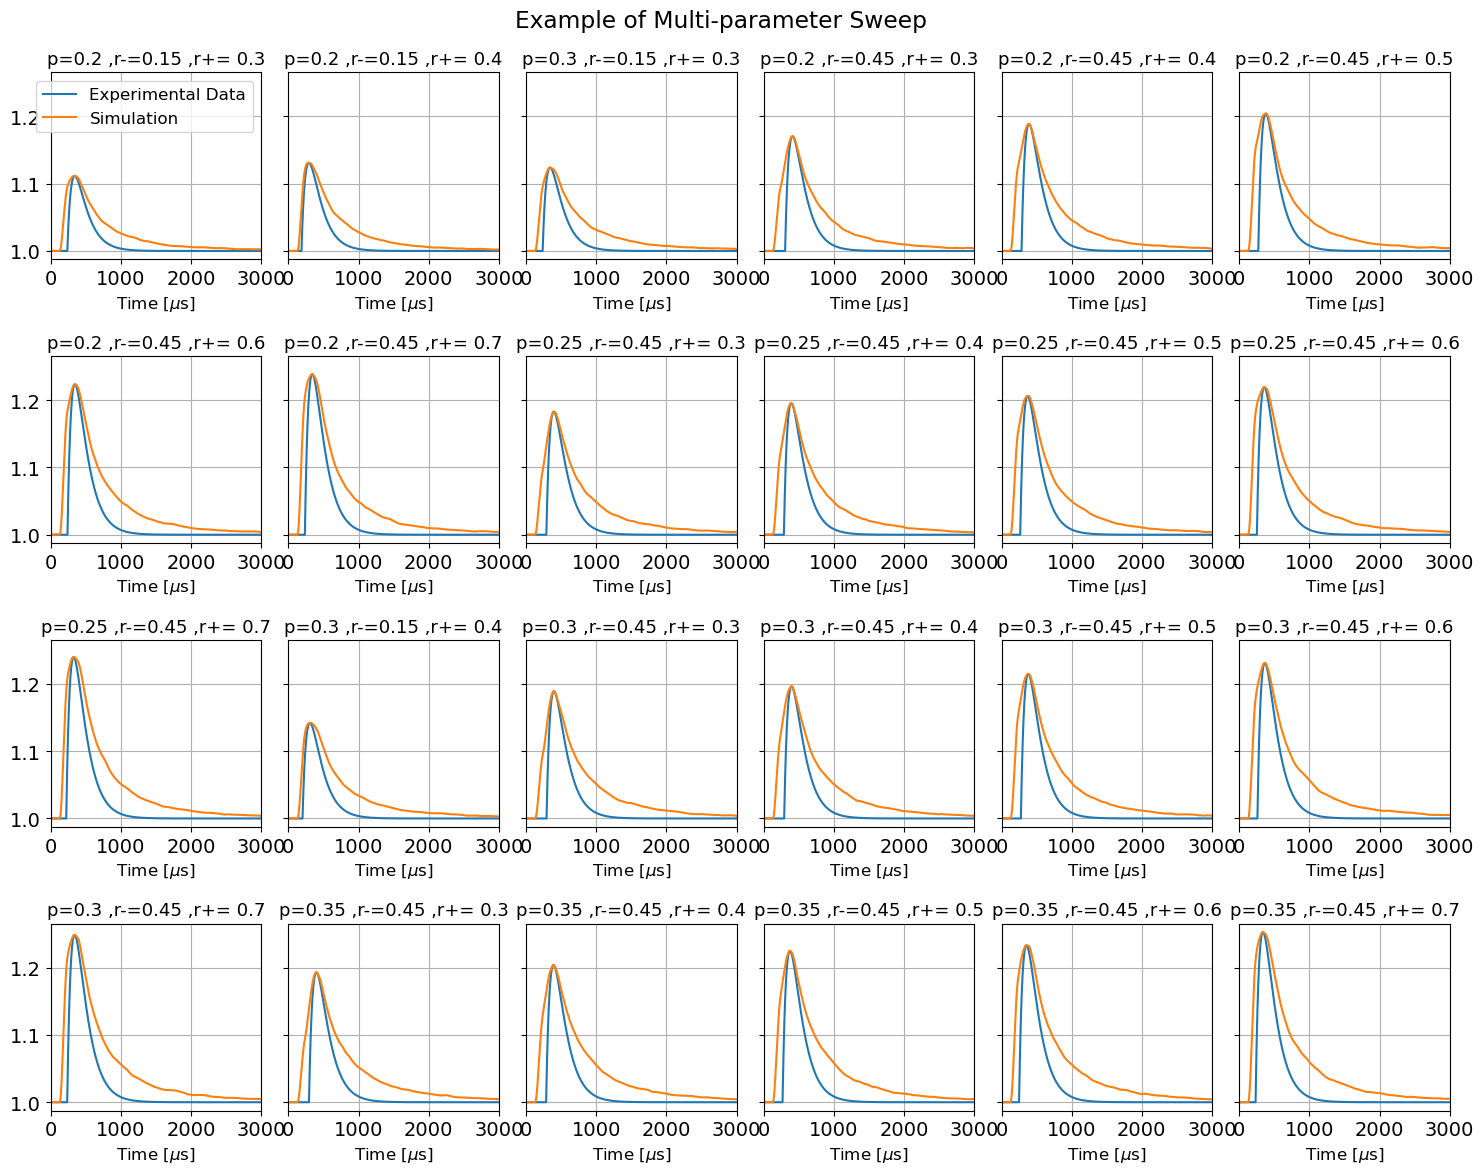

In [15]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.pkl')
config_list= glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.csv')
fig, axs = plt.subplots(4, 6 , figsize=(15,12),  sharey=True)
ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
chi_squared = np.empty_like(file_list, dtype=float)

for i, f1 in enumerate(file_list):
    if i >= 24:
        continue
    with open(f1, 'rb') as file:
        evap = pickle.load(file)
    config_file = pandas.read_csv(config_list[i])
    s1, s2 , time =generate_waveform(evap)
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

    chi_squared[i] = np.sum((s1+1)**2 - (new_template+1)**2/(new_template+1))
    ax[i].plot(time * 1e6, new_template + 1, label = 'Experimental Data')

    ax[i].plot(time * 1e6, s1 + 1, label='Simulation')
    ax[i].set_xlim(0, 3000)
    # ax[i].plot(time, s2, label='CPD2')
    eff = config_file['evap_eff'].astype('str')
    title = 'p='+ eff[0] + ' ,r-=' + eff[1] + ' ,r+= ' + eff[2]
    ax[i].set_title(title, fontsize=13)
    if i==0: ax[i].legend(fontsize=12)
    ax[i].grid()
    ax[i].set_xlabel(r'Time [$\mu$s]', fontsize=12)
fig.suptitle("Example of Multi-parameter Sweep")
fig.tight_layout()
fig.savefig('./data/plots/Testing_different_flavors.png', dpi = 250)

In [ ]:
np.min(chi_squared)

In [ ]:
config_file = pandas.read_csv(config_list[1])
evap = config_file['evap_eff'].astype('str')
evap[:]

In [ ]:
print(mins_1)

In [ ]:

plt.plot(time, s1)
time_2 = np.linspace(0, 0.005, int(9375))

plt.plot(time_2, peak * template_1)

In [ ]:
peak_index_signal = np.argmax(s1)
peak_index_template = np.argmax(template_1)
diff = peak_index_signal - peak_index_template
before_pad = int(diff)
before_pad = np.nonzero(s1)[0][0]
after_pad = len(s1) - len(template_1) -before_pad

new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)

plt.plot(time, s1)
plt.plot(time, peak * new_template)
scipy.stats.chisquare(s1, peak * new_template)

In [ ]:
extract_pulse(['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/testing_flavor_change.pkl'])


In [ ]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/testing_flavor_change.pkl', 'rb') as f:
    evap = pickle.load(f)

template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
s1, s2, time = generate_waveform(evap)
peak = np.max(s1)

peak_index_signal = np.argmax(s1)
peak_index_template = np.argmax(template_1)
diff = peak_index_signal - peak_index_template
before_pad = int(diff)
after_pad = len(s1) - len(template_1) -before_pad
new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

print(np.sum((s1+1)**2 - (new_template+1)**2/(new_template+1)))
plt.plot(time, new_template, label='template')
plt.plot(time, s1, label='simulation pulse')
plt.xlim(0, 0.002)
plt.legend()



In [ ]:

trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/fit_waveform/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/fit_waveform/config_*.npy')
config_list

In [3]:
# Trying to fit to the 7D parameter sweep: debugging analysis. 


trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/fit_waveform/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/fit_waveform/config_*.npy')
matched_pairs = get_file_map(config_list=config_list, trial_list=trial_list)
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
chi_squared = np.ones((16000), dtype=float)
for num, (config, trial) in matched_pairs.items():
    if num < 4:
        continue
    if num > 50:
        break
    with open(trial, 'rb') as file:
        evap = pickle.load(file)
    s1, s2 , time =generate_waveform(evap)
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

    chi_squared[num] = np.sum((s1+1)**2 - (new_template+1)**2/(new_template+1))
np.save('/home/cveihmeyer_umass_edu/HeST/data/chi_squared', chi_squared)

In [ ]:
chi_squared = np.load('/home/cveihmeyer_umass_edu/HeST/data/chi_squared_latter_half.npy')
plt.plot(chi_squared)
plt.yscale('log')
plt.axhline(4e4)
plt.xlim(12400, 12500)

In [ ]:
directory = '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/fit_waveform'


files_of_interest = [os.path.join(directory, 'trial_256.pkl'), os.path.join(directory, 'trial_257.pkl'), os.path.join(directory, 'trial_1030.pkl'), os.path.join(directory, 'trial_1041.pkl'),  os.path.join(directory, 'trial_1095.pkl'), os.path.join(directory, 'trial_2305.pkl'), os.path.join(directory, 'trial_2306.pkl'), os.path.join(directory, 'trial_3076.pkl'),  os.path.join(directory, 'trial_3077.pkl')]
files_of_interest = [os.path.join(directory, 'trial_1030.pkl'), os.path.join(directory, 'trial_1041.pkl'), os.path.join(directory, 'trial_3077.pkl')]

In [ ]:
extract_pulse(files_of_interest)

In [ ]:
fig, axs = plt.subplots(2, 2, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

for i, f1 in enumerate(files_of_interest):

    with open(f1, 'rb') as file:
        evap = pickle.load(file)
    s1, s2 , time =generate_waveform(evap)
    peak_1 = np.max(s1)
    peak_index_signal_1 = np.argmax(s1)
    peak_index_template_1 = np.argmax(template_1)
    diff = peak_index_signal_1 - peak_index_template_1
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template_1 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_1

    peak_2 = np.max(s2)
    peak_index_signal_2 = np.argmax(s2)
    peak_index_template_2 = np.argmax(template_2)
    diff = peak_index_signal_2 - peak_index_template_2
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template_2 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_2




    ax[i].plot(time, new_template_1, label = 'CPD1 template')
    ax[i].plot(time, new_template_2, label = 'CPD2 template')
    ax[i].plot(time, s1, label='CPD1 simulation')
    ax[i].set_xlim(0, 0.001)
    ax[i].plot(time, s2, label='CPD2 simulation')
    title = f1.split('/')[-1]
    ax[i].set_title(title)
    ax[i].legend()
    ax[i].grid()
    ax[i].set_ylim(0, 15)
fig.tight_layout()
 

(0.0, 1000.0)

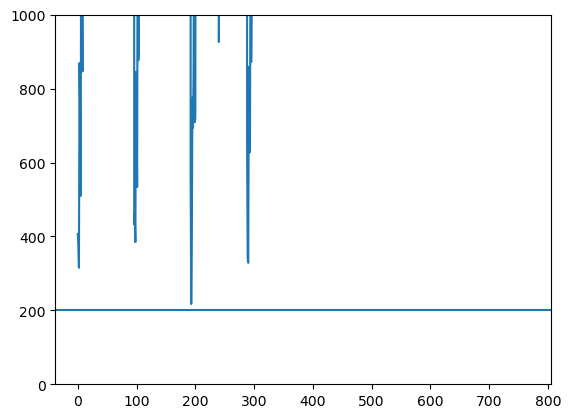

In [ ]:
chi_squared = np.load('/home/cveihmeyer_umass_edu/HeST/data/zoom_in.npy')
plt.plot(chi_squared)
# plt.yscale('log')
plt.axhline(200)
plt.ylim(0, 1e3)
# plt.xlim(190 ,200)


In [5]:
files_of_interest= ['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_0.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_96.pkl','/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_97.pkl','/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_98.pkl','/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_101.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_104.pkl','/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_193.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_194.pkl']

In [ ]:
extract_pulse(files_of_interest)

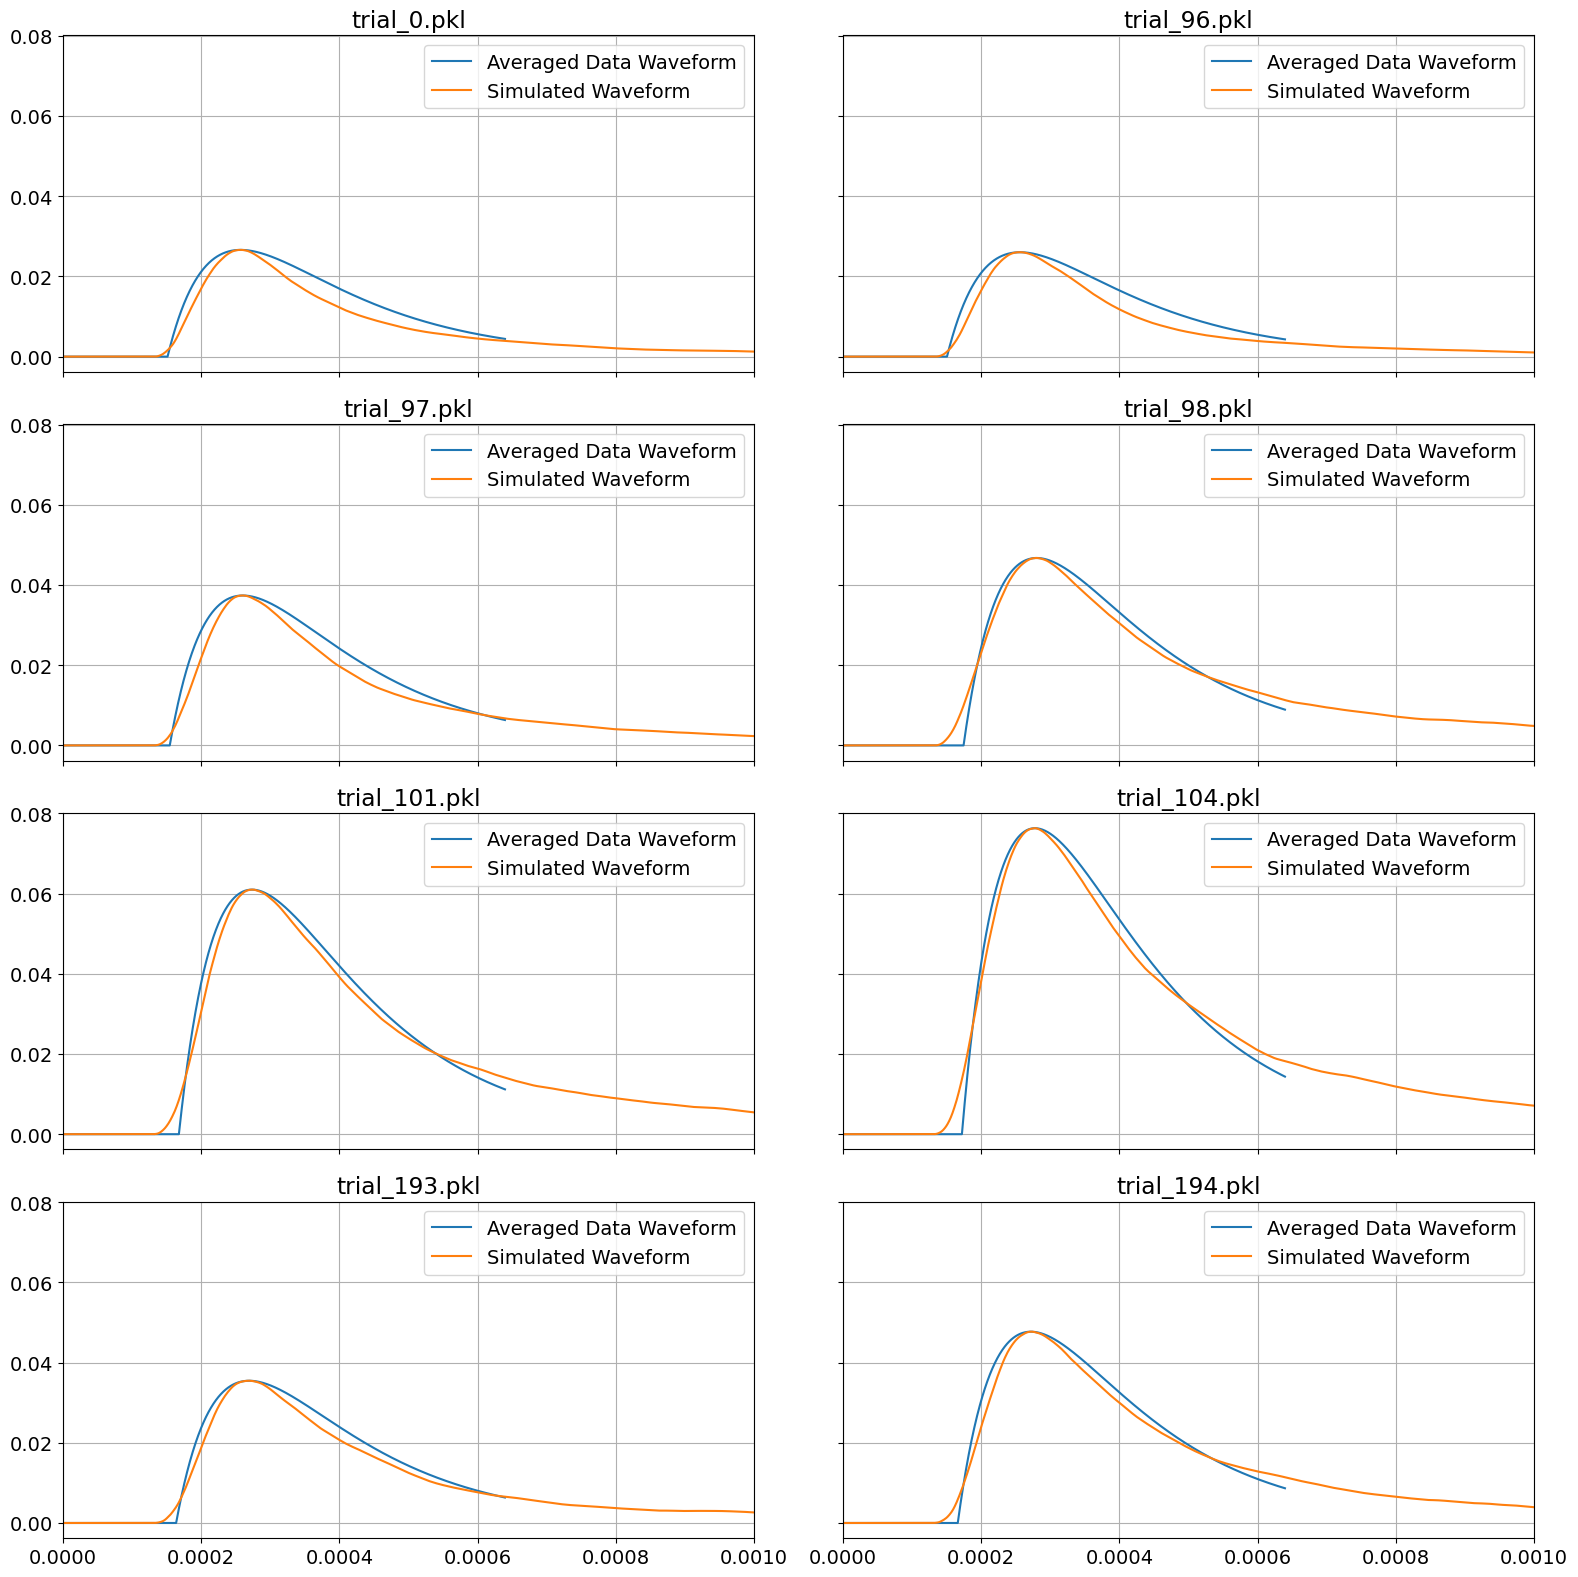

In [6]:
fig, axs = plt.subplots(4, 2, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_normalized_template.npy')
template_1 = template[2]
template_2 = template[3]

for i, f1 in enumerate(files_of_interest):

    with open(f1, 'rb') as file:
        evap = pickle.load(file)
    s1, s2 , time =generate_waveform(evap)
    peak_1 = np.max(s1)
    peak_index_signal_1 = np.argmax(s1)
    peak_index_template_1 = np.argmax(template_1)
    diff = peak_index_signal_1 - peak_index_template_1
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template_1 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_1

    peak_2 = np.max(s2)
    peak_index_signal_2 = np.argmax(s2)
    peak_index_template_2 = np.argmax(template_2)
    diff = peak_index_signal_2 - peak_index_template_2
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template_2 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_2




    ax[i].plot(time[:1600], new_template_1[:1600], label = 'Averaged Data Waveform')
    # ax[i].plot(time, new_template_2, label = 'CPD2 template')
    ax[i].plot(time, s1, label='Simulated Waveform')
    ax[i].set_xlim(0, 0.001)
    # ax[i].plot(time, s2, label='CPD2 simulation')
    title = f1.split('/')[-1]
    ax[i].set_title(title)
    ax[i].legend()
    ax[i].grid()
fig.tight_layout()
 
# fig.savefig('./data/plots/pretty_good_parameters.png')

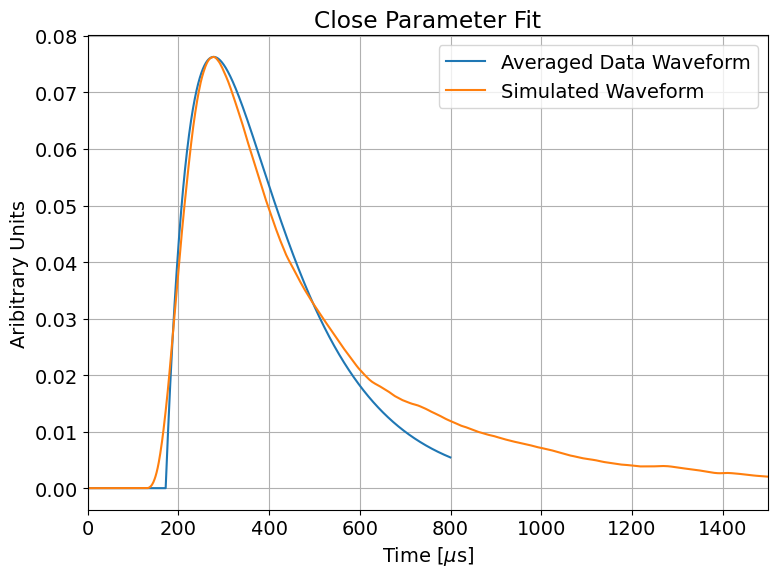

In [13]:


fig, ax = plt.subplots(1, 1, figsize = (8,6), sharex=True, sharey=True)


with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/zoom_in_1031/trial_104.pkl', 'rb') as f:

    evap = pickle.load(f)

s1, s2 , time =generate_waveform(evap)
peak_1 = np.max(s1)
peak_index_signal_1 = np.argmax(s1)
peak_index_template_1 = np.argmax(template_1)
diff = peak_index_signal_1 - peak_index_template_1
before_pad = int(diff)
after_pad = len(s1) - len(template_1) -before_pad
new_template_1 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_1

peak_2 = np.max(s2)
peak_index_signal_2 = np.argmax(s2)
peak_index_template_2 = np.argmax(template_2)
diff = peak_index_signal_2 - peak_index_template_2
before_pad = int(diff)
after_pad = len(s1) - len(template_1) -before_pad
new_template_2 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_2




ax.plot(time[:2000] * 1e6, new_template_1[:2000], label = 'Averaged Data Waveform')
# ax[i].plot(time, new_template_2, label = 'CPD2 template')
ax.plot(time * 1e6, s1, label='Simulated Waveform')
ax.set_xlim(0, 1500)
# ax[i].plot(time, s2, label='CPD2 simulation')
title = 'Close Parameter Fit'
ax.set_title(title)
ax.set_xlabel(r'Time [$\mu$s]')
ax.set_ylabel(r'Aribitrary Units')
ax.legend()
ax.grid()
fig.tight_layout()
fig.savefig('./data/plots/Best_fit.png', dpi = 250)

In [ ]:
print(len(evap.arrivalTimes_us[1]))

In [8]:
amps = np.load('./data/Double_pulse_amps.npy')


In [9]:
np.shape(amps)
mask = amps[:,1]>0
cpd_2_evap = amps[:,1][mask]
cpd_1_evap = amps[:,3][mask]

# quick cuts now


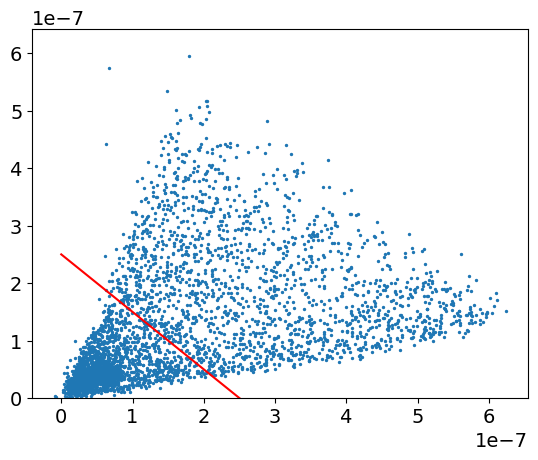

In [10]:
plt.scatter(cpd_1_evap, cpd_2_evap, s = 2)
# make cuts to get rid of aluminum blob (I think)
def linear(x,a,b):
    return a * x + b
c1 = -1
c2 = 2.5e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.ylim(0, )


al_blob_cut = cpd_2_evap > linear(cpd_1_evap, c1, c2)

Text(0.5, 1.0, 'Partition Data selection')

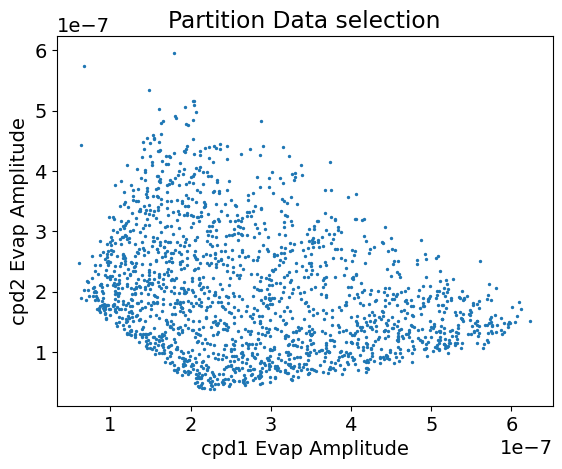

In [11]:
plt.scatter(cpd_1_evap[al_blob_cut], cpd_2_evap[al_blob_cut], s=2)
plt.xlabel('cpd1 Evap Amplitude')
plt.ylabel('cpd2 Evap Amplitude')
plt.title('Partition Data selection')

In [12]:
partition = (cpd_2_evap[al_blob_cut]-cpd_1_evap[al_blob_cut])/(np.abs(cpd_1_evap[al_blob_cut])+np.abs(cpd_2_evap[al_blob_cut]))

Text(0.5, 1.0, 'Real Waveform data partition')

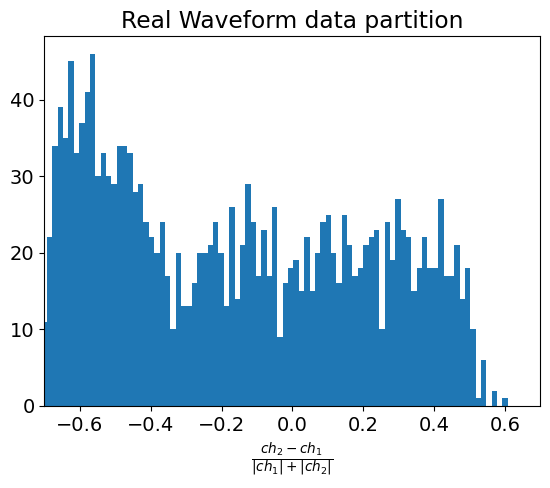

In [13]:
plt.hist(partition, bins = 100)
plt.xlabel(r'$\frac{ch_2-ch_1}{|ch_1| + |ch_2|}$')
plt.xlim(-.7, 0.7)
plt.title('Real Waveform data partition')

In [ ]:
# time ti scrape the ch1 ch2 sweep for data. 

file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/ch1_ch2_comparison/possible_params/trial_*.pkl')
cpd1_sum = np.zeros_like(file_list)
cpd2_sum = np.zeros_like(file_list)
for ii, f in enumerate(file_list):
    with open(f, 'rb') as f_1:
        evap = pickle.load(f)
    cpd1_sum[ii] = len(evap.arrivalTimes_us[0])
    cpd2_sum[ii] = len(evap.arrivalTimes_us[1])

0.9999999999999997


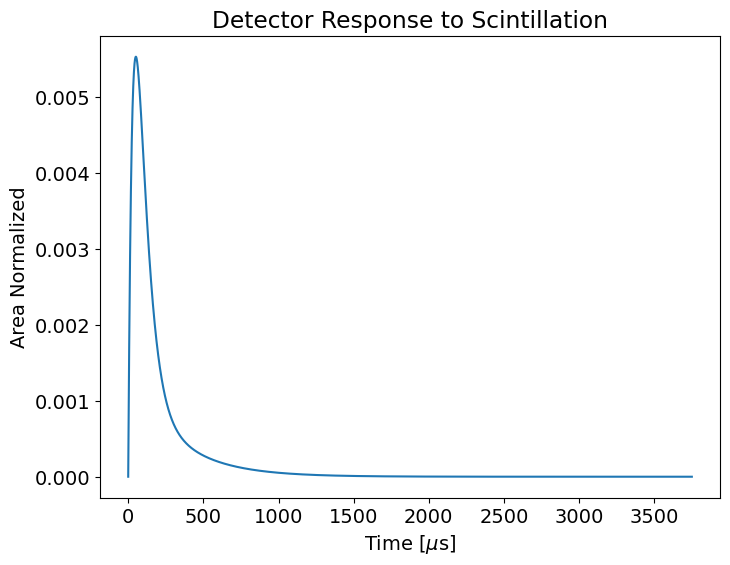

In [10]:
# need to fix the template issue: normalize by the area. 
templates = np.load('./data/dispersion_curves/shortened_template.npy')
time = np.arange(0, 0.4e-3 * 9375, 0.4e-3)*1e3
area_1 = np.sum(np.diff(time) * templates[0,:-1])
area_2 = np.sum(np.diff(time) * templates[1,:-1])
templates[0, :] /= area_1
templates[1, :] /= area_2
# resave this to make the analysis look better (I think). 
plt.figure(figsize=(8,6))
for i in range(4):
    if i< 1:
        plt.plot(time , templates[i,:])
    else:
        continue
        plt.plot(time , templates[i,:], label = f'evaporation cpd {i-1}')
# plt.ylim(0, 0.05)
# plt.legend()
plt.xlabel(r'Time [$\mu$s]')
plt.title('Detector Response to Scintillation')
plt.ylabel('Area Normalized')

print(np.sum(templates[0,:-1] * np.diff(time)))
plt.savefig('./data/plots/area_normalized_template.png')

In [34]:
np.save('./data/dispersion_curves/shortened_normalized_template.npy', templates)

In [ ]:
files_of_interest= glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/*.pkl')



extract_pulse(files_of_interest)
 

In [ ]:
fig, axs = plt.subplots(1, 1, figsize = (16,16), sharex=True, sharey=True)
# ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_normalized_template.npy')
template_1 = template[2]
template_2 = template[3]


f1 = files_of_interest[1]
i =0
with open(f1, 'rb') as file:
    evap = pickle.load(file)
s1, s2 , time =generate_waveform(evap)


title = f1.split('/')[-1]
axs.plot(time, s1, label='CPD1 simulation')
axs.set_xlim(0, 0.003)
axs.plot(time, s2, label='CPD2 simulation')
axs.set_title(title)
axs.legend()
axs.grid()
fig.tight_layout()


In [ ]:
prob_list = 1.0,1.0,1.0,1.0,1.0,1.0,
bins = [0.0, 0.6, 1.7, 2.2, 3.78, 4.5, 5.2]
talk_plots = './data/plots/'


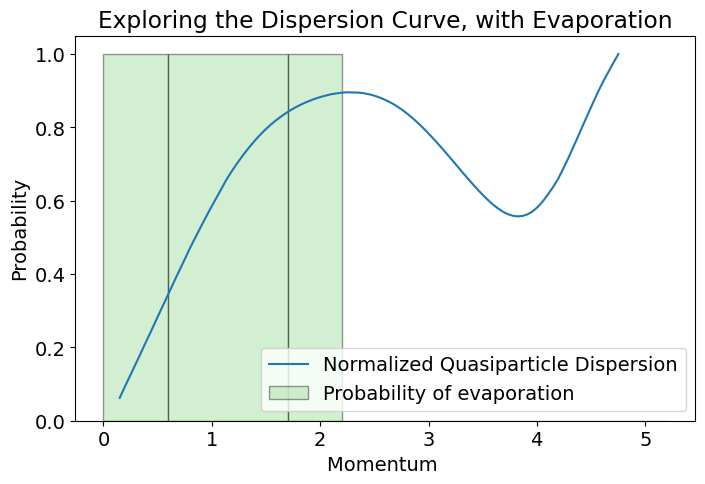

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(bins[:-1], prob_list,  align='edge', width = np.diff(bins), edgecolor='black', alpha = 0.4, color='#90D890', label = 'Probability of evaporation')
p = np.linspace(0.15, 4.75, 100)
plt.plot(p, detection.QP_dispersion(p)/np.max(detection.QP_dispersion(p)), label = 'Normalized Quasiparticle Dispersion')
plt.legend(loc='lower right')
plt.title('Exploring the Dispersion Curve, with Evaporation')
plt.xlabel(r'Momentum ')
plt.ylabel('Probability')
plt.savefig(os.path.join(talk_plots, 'all_prob_distribution.png'), dpi = 300)


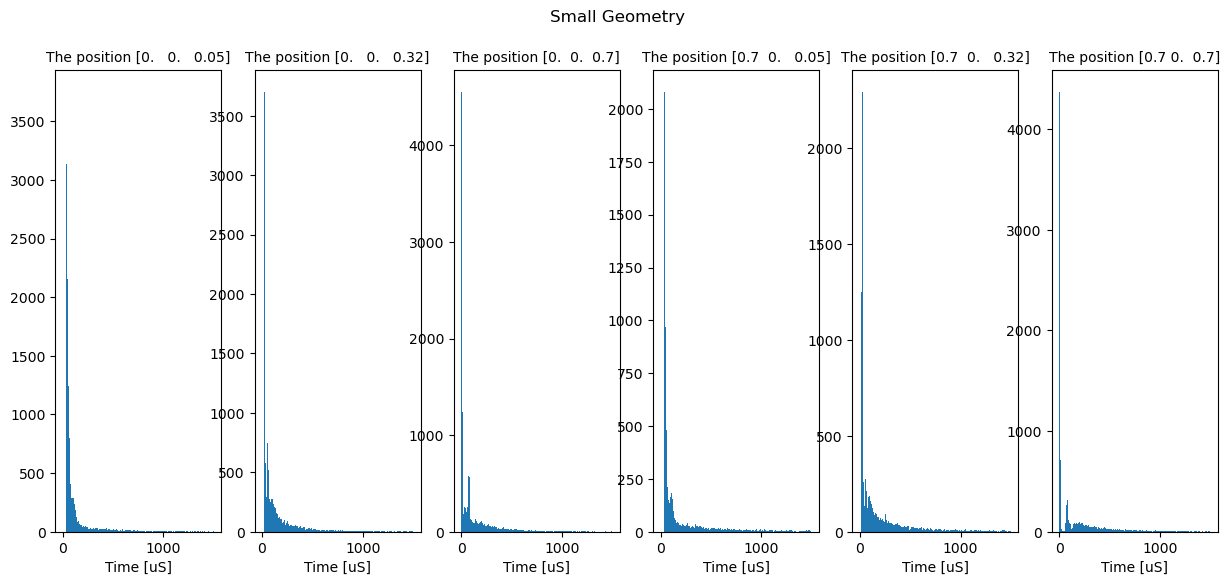

In [12]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/small/trial_*.npy')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/small/config_*.npy')

small_dictionary = get_file_map(config_list, trial_list)
small_dictionary

fig, ax = plt.subplots(1,6, figsize = (15,6))

fig.suptitle("Small Geometry")
for num, (config, trial) in small_dictionary.items():
    trial_data = np.load(trial)
    config = np.load(config, allow_pickle=True).item()
    title = 'The position ' + str(np.round(config['pos'], 2))
    ax[num].hist(trial_data[:,0], bins=200, range=(0,1500))
    ax[num].set_title(title, fontsize=10)
    ax[num].set_xlabel('Time [uS]')


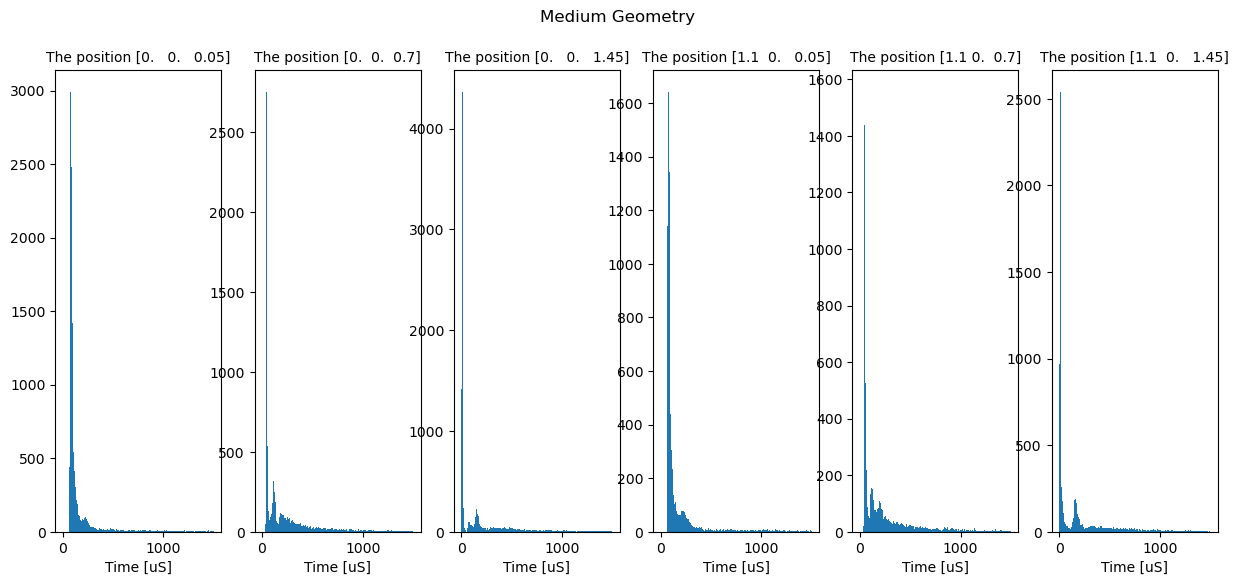

In [14]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/med/trial_*.npy')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/med/config_*.npy')

small_dictionary = get_file_map(config_list, trial_list)
small_dictionary

fig, ax = plt.subplots(1,6, figsize = (15,6))

fig.suptitle("Medium Geometry")
for num, (config, trial) in small_dictionary.items():
    trial_data = np.load(trial)
    config = np.load(config, allow_pickle=True).item()
    title = 'The position ' + str(np.round(config['pos'], 2))
    ax[num].hist(trial_data[:,0], bins=200, range=(0,1500))
    ax[num].set_title(title, fontsize=10)
    ax[num].set_xlabel('Time [uS]')



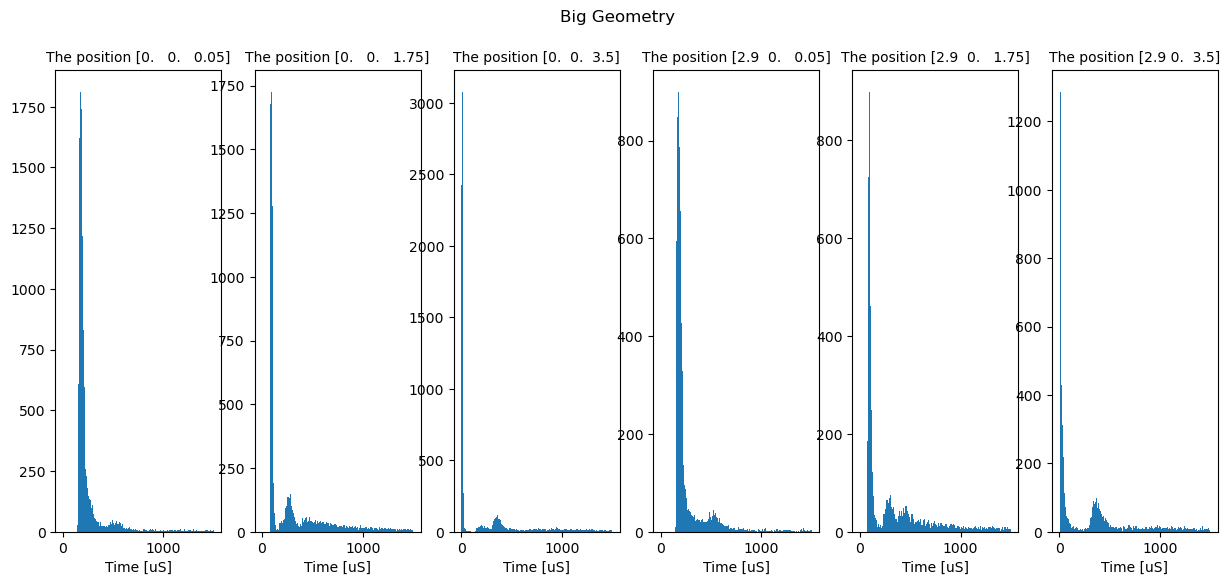

In [ ]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/trial_*.npy')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/config_*.npy')

small_dictionary = get_file_map(config_list, trial_list)
small_dictionary

fig, ax = plt.subplots(1,6, figsize = (15,6))

fig.suptitle("Big Geometry")
for num, (config, trial) in small_dictionary.items():
    trial_data = np.load(trial)
    config = np.load(config, allow_pickle=True).item()
    title = 'The position ' + str(np.round(config['pos'], 2))
    ax[num].hist(trial_data[:,0], bins=200, range=(0,1500))
    ax[num].set_title(title, fontsize=10)
    ax[num].set_xlabel('Time [uS]')



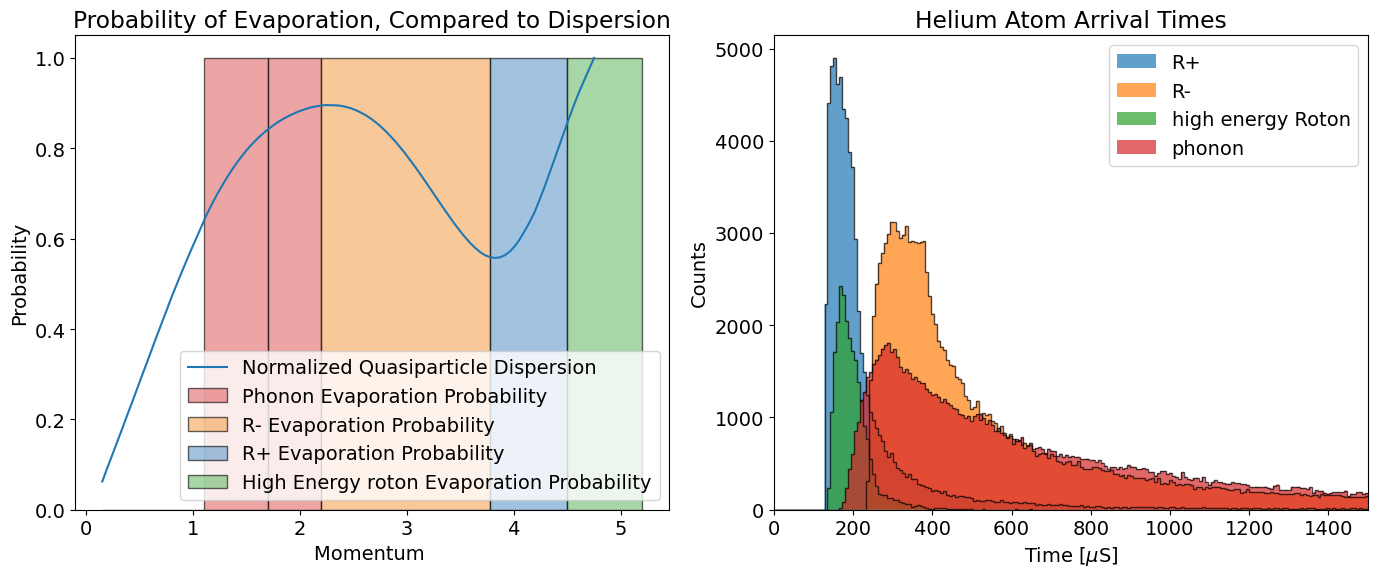

In [ ]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/accept_all_through.pkl', 'rb') as f:
    evap = pickle.load(f)

fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,2, figsize =(14, 6))

for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='stepfilled' , label = value)
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='step' , color='black')
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


prob_list = 0.0,1.0,1.0,1.0,1.0,1.0,
bins = [0.15, 1.1, 1.7, 2.2, 3.78, 4.5, 5.2]



ax[0].bar(bins[:3], prob_list[:3],  align='edge', width = np.diff(bins[:4]), edgecolor='black', alpha = 0.6, color=['#e26768', '#e26768', '#e26768'], label = 'Phonon Evaporation Probability')
ax[0].bar(bins[3:4], prob_list[3:4],  align='edge', width = np.diff(bins[3:5]), edgecolor='black', alpha = 0.6, color=[ '#f4a454'], label = 'R- Evaporation Probability')
ax[0].bar(bins[4:-2], prob_list[4:-1],  align='edge', width = np.diff(bins[4:-1]), edgecolor='black', alpha = 0.6, color=[ '#649ccc'], label = 'R+ Evaporation Probability')
ax[0].bar(bins[5:-1], prob_list[5:],  align='edge', width = np.diff(bins[5:]), edgecolor='black', alpha = 0.6, color=[ '#6cbc6c'], label = 'High Energy roton Evaporation Probability')
p = np.linspace(0.15, 4.75, 100)
ax[0].plot(p, detection.QP_dispersion(p)/np.max(detection.QP_dispersion(p)), label = 'Normalized Quasiparticle Dispersion')
ax[0].legend(loc='lower right')
ax[0].set_title('Probability of Evaporation, Compared to Dispersion')
ax[0].set_xlabel(r'Momentum ')
ax[0].set_ylabel('Probability')
fig.tight_layout()


# plt.savefig('./data/plots/arrival_times_by_flavor.png', dpi=250)

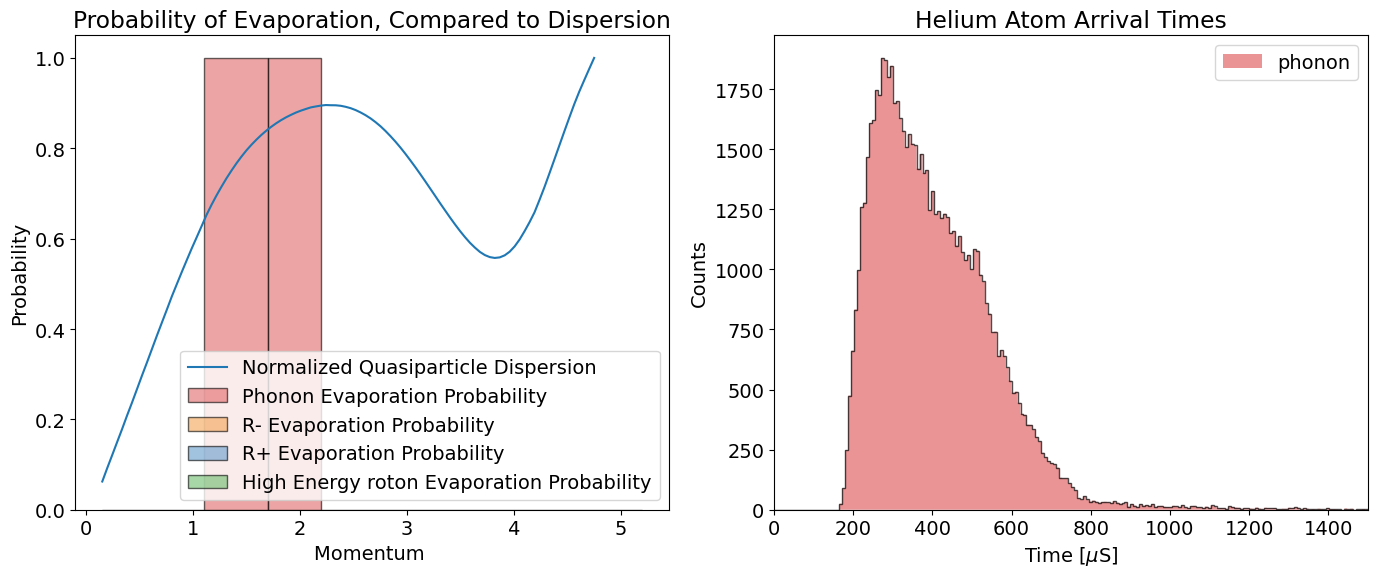

In [23]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/only_phonons.pkl', 'rb') as f:
    evap = pickle.load(f)

fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,2, figsize =(14, 6))

for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True, color = '#e26768', histtype='stepfilled' , label = value)
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='step' , color='black')
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


prob_list = 0.0,1.0,1.0,0.0,0.0,0.0,
bins = [0.15, 1.1, 1.7, 2.2, 3.78, 4.5, 5.2]



ax[0].bar(bins[:3], prob_list[:3],  align='edge', width = np.diff(bins[:4]), edgecolor='black', alpha = 0.6, color=['#e26768', '#e26768', '#e26768'], label = 'Phonon Evaporation Probability')
ax[0].bar(bins[3:4], prob_list[3:4],  align='edge', width = np.diff(bins[3:5]), edgecolor='black', alpha = 0.6, color=[ '#f4a454'], label = 'R- Evaporation Probability')
ax[0].bar(bins[4:-2], prob_list[4:-1],  align='edge', width = np.diff(bins[4:-1]), edgecolor='black', alpha = 0.6, color=[ '#649ccc'], label = 'R+ Evaporation Probability')
ax[0].bar(bins[5:-1], prob_list[5:],  align='edge', width = np.diff(bins[5:]), edgecolor='black', alpha = 0.6, color=[ '#6cbc6c'], label = 'High Energy roton Evaporation Probability')
p = np.linspace(0.15, 4.75, 100)
ax[0].plot(p, detection.QP_dispersion(p)/np.max(detection.QP_dispersion(p)), label = 'Normalized Quasiparticle Dispersion')
ax[0].legend(loc='lower right')
ax[0].set_title('Probability of Evaporation, Compared to Dispersion')
ax[0].set_xlabel(r'Momentum ')
ax[0].set_ylabel('Probability')
fig.tight_layout()


plt.savefig('./data/plots/only_phonons.png', dpi=250)

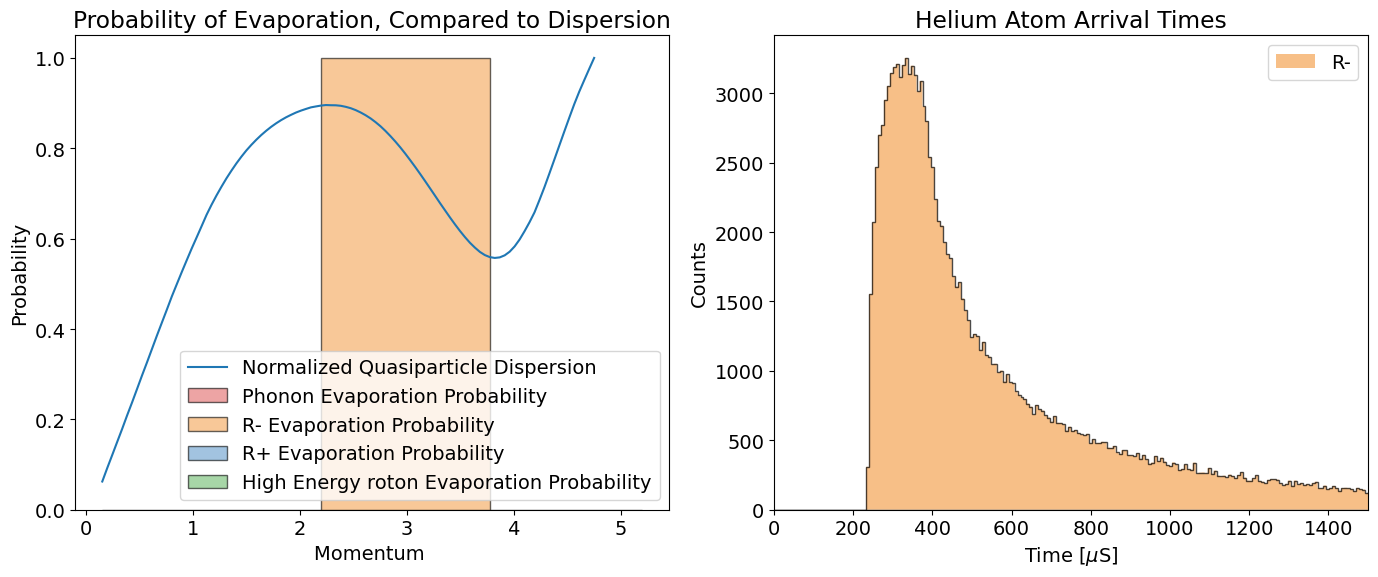

In [30]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/only_R_minus.pkl', 'rb') as f:
    evap = pickle.load(f)

fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,2, figsize =(14, 6))

for value in np.unique(fs):
    if value=='slow moving':
        continue
    if value=='phonon':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True, color = '#f4a454', histtype='stepfilled' , label = value)
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='step' , color='black')
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


prob_list = 0.0,0.0,0.0,1.0,0.0,0.0,
bins = [0.15, 1.1, 1.7, 2.2, 3.78, 4.5, 5.2]



ax[0].bar(bins[:3], prob_list[:3],  align='edge', width = np.diff(bins[:4]), edgecolor='black', alpha = 0.6, color=['#e26768', '#e26768', '#e26768'], label = 'Phonon Evaporation Probability')
ax[0].bar(bins[3:4], prob_list[3:4],  align='edge', width = np.diff(bins[3:5]), edgecolor='black', alpha = 0.6, color=[ '#f4a454'], label = 'R- Evaporation Probability')
ax[0].bar(bins[4:-2], prob_list[4:-1],  align='edge', width = np.diff(bins[4:-1]), edgecolor='black', alpha = 0.6, color=[ '#649ccc'], label = 'R+ Evaporation Probability')
ax[0].bar(bins[5:-1], prob_list[5:],  align='edge', width = np.diff(bins[5:]), edgecolor='black', alpha = 0.6, color=[ '#6cbc6c'], label = 'High Energy roton Evaporation Probability')
p = np.linspace(0.15, 4.75, 100)
ax[0].plot(p, detection.QP_dispersion(p)/np.max(detection.QP_dispersion(p)), label = 'Normalized Quasiparticle Dispersion')
ax[0].legend(loc='lower right')
ax[0].set_title('Probability of Evaporation, Compared to Dispersion')
ax[0].set_xlabel(r'Momentum ')
ax[0].set_ylabel('Probability')
fig.tight_layout()


fig.savefig('./data/plots/only_R_minus.png', dpi=250)

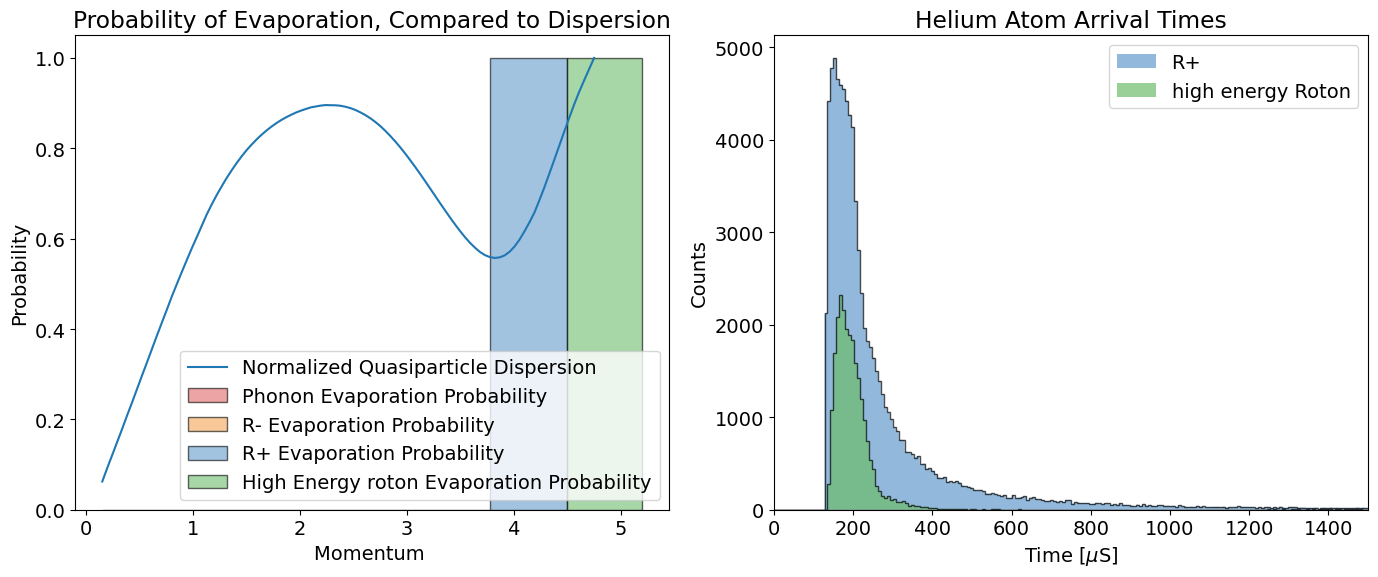

In [29]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/only_R_plus.pkl', 'rb') as f:
    evap = pickle.load(f)

fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,2, figsize =(14, 6))

for value in np.unique(fs):
    if value=='slow moving':
        continue
    if value=='phonon' or value=='R-':
        continue
    if value=='R+':
        mask = (fs == value)
        ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='stepfilled', color = '#649ccc' , label = value)
        ax[1].set_title(f'Helium Atom Arrival Times')
        ax[1].legend()
        ax[1].set_xlabel(r"Time [$\mu$S]" )
        ax[1].set_ylabel("Counts" )
        ax[1].set_xlim(0, 1500)
    else:
        mask = (fs == value)
        ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='stepfilled', color = '#6cbc6c' , label = value)
        ax[1].set_title(f'Helium Atom Arrival Times')
        ax[1].legend()
        ax[1].set_xlabel(r"Time [$\mu$S]" )
        ax[1].set_ylabel("Counts" )
        ax[1].set_xlim(0, 1500)








for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='step' , color='black')
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


prob_list = 0.0,0.0,0.0,0.0,1.0,1.0,
bins = [0.15, 1.1, 1.7, 2.2, 3.78, 4.5, 5.2]



ax[0].bar(bins[:3], prob_list[:3],  align='edge', width = np.diff(bins[:4]), edgecolor='black', alpha = 0.6, color=['#e26768', '#e26768', '#e26768'], label = 'Phonon Evaporation Probability')
ax[0].bar(bins[3:4], prob_list[3:4],  align='edge', width = np.diff(bins[3:5]), edgecolor='black', alpha = 0.6, color=[ '#f4a454'], label = 'R- Evaporation Probability')
ax[0].bar(bins[4:-2], prob_list[4:-1],  align='edge', width = np.diff(bins[4:-1]), edgecolor='black', alpha = 0.6, color=[ '#649ccc'], label = 'R+ Evaporation Probability')
ax[0].bar(bins[5:-1], prob_list[5:],  align='edge', width = np.diff(bins[5:]), edgecolor='black', alpha = 0.6, color=[ '#6cbc6c'], label = 'High Energy roton Evaporation Probability')
p = np.linspace(0.15, 4.75, 100)
ax[0].plot(p, detection.QP_dispersion(p)/np.max(detection.QP_dispersion(p)), label = 'Normalized Quasiparticle Dispersion')
ax[0].legend(loc='lower right')
ax[0].set_title('Probability of Evaporation, Compared to Dispersion')
ax[0].set_xlabel(r'Momentum ')
ax[0].set_ylabel('Probability')
fig.tight_layout()


plt.savefig('./data/plots/only_r_plus.png', dpi=250)

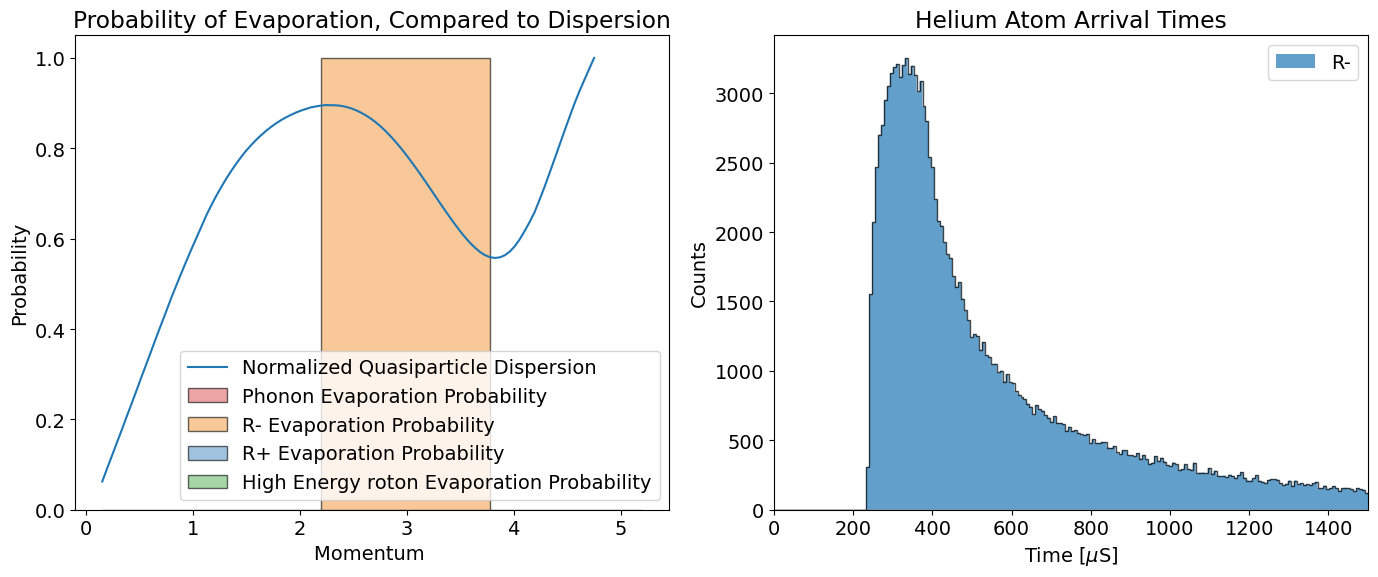

In [19]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/only_R_minus.pkl', 'rb') as f:
    evap = pickle.load(f)

fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,2, figsize =(14, 6))

for value in np.unique(fs):
    if value=='slow moving':
        continue
    if value=='phonon':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='stepfilled' , label = value)
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax[1].hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True,histtype='step' , color='black')
    ax[1].set_title(f'Helium Atom Arrival Times')
    ax[1].legend()
    ax[1].set_xlabel(r"Time [$\mu$S]" )
    ax[1].set_ylabel("Counts" )
    ax[1].set_xlim(0, 1500)


prob_list = 0.0,0.0,0.0,1.0,0.0,0.0,
bins = [0.15, 1.1, 1.7, 2.2, 3.78, 4.5, 5.2]



ax[0].bar(bins[:3], prob_list[:3],  align='edge', width = np.diff(bins[:4]), edgecolor='black', alpha = 0.6, color=['#e26768', '#e26768', '#e26768'], label = 'Phonon Evaporation Probability')
ax[0].bar(bins[3:4], prob_list[3:4],  align='edge', width = np.diff(bins[3:5]), edgecolor='black', alpha = 0.6, color=[ '#f4a454'], label = 'R- Evaporation Probability')
ax[0].bar(bins[4:-2], prob_list[4:-1],  align='edge', width = np.diff(bins[4:-1]), edgecolor='black', alpha = 0.6, color=[ '#649ccc'], label = 'R+ Evaporation Probability')
ax[0].bar(bins[5:-1], prob_list[5:],  align='edge', width = np.diff(bins[5:]), edgecolor='black', alpha = 0.6, color=[ '#6cbc6c'], label = 'High Energy roton Evaporation Probability')
p = np.linspace(0.15, 4.75, 100)
ax[0].plot(p, detection.QP_dispersion(p)/np.max(detection.QP_dispersion(p)), label = 'Normalized Quasiparticle Dispersion')
ax[0].legend(loc='lower right')
ax[0].set_title('Probability of Evaporation, Compared to Dispersion')
ax[0].set_xlabel(r'Momentum ')
ax[0].set_ylabel('Probability')
fig.tight_layout()


# plt.savefig('./data/plots/arrival_times_by_flavor.png', dpi=250)

In [ ]:
color_list = ['#e26768', '#f4a454', '#649ccc',  '#6cbc6c']

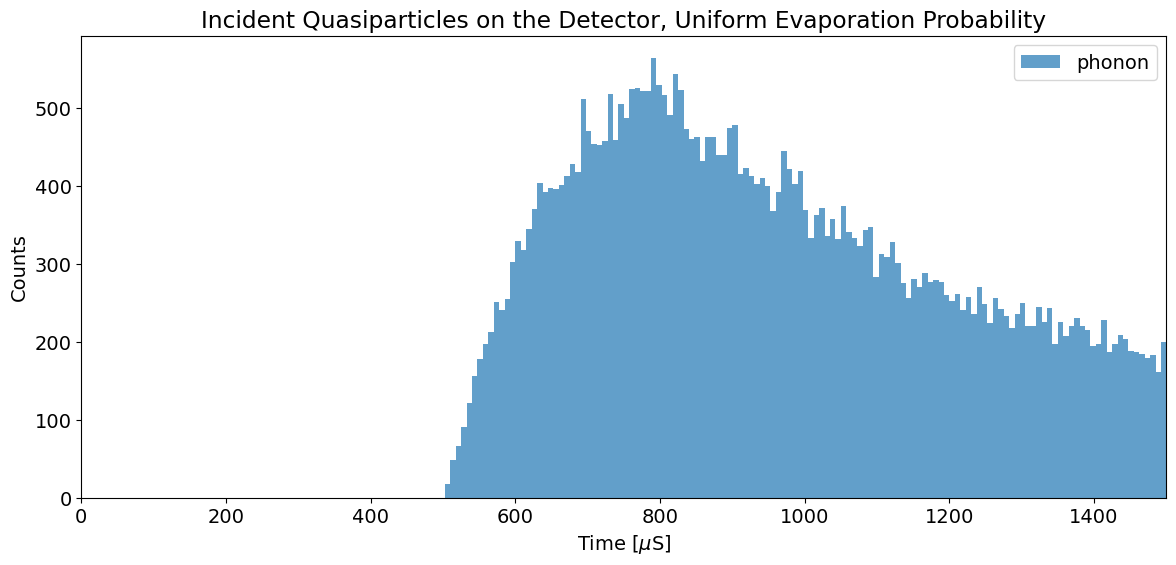

In [22]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/only_R-.pkl', 'rb') as f:
    evap = pickle.load(f)


fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,1, figsize =(14, 6))
for value in np.unique(fs):
    if value=='slow moving':
        continue
    mask = (fs == value)
    ax.hist(total_arrival_times[mask], bins = 400, range = [0,3000], alpha= 0.7,stacked=True, label = value)
    ax.set_title(f'Incident Quasiparticles on the Detector, Uniform Evaporation Probability')
    ax.legend()
    ax.set_xlabel(r"Time [$\mu$S]" )
    ax.set_ylabel("Counts" )
    ax.set_xlim(0, 1500)

# plt.savefig('./data/plots/only_r_minus.png', dpi=250)

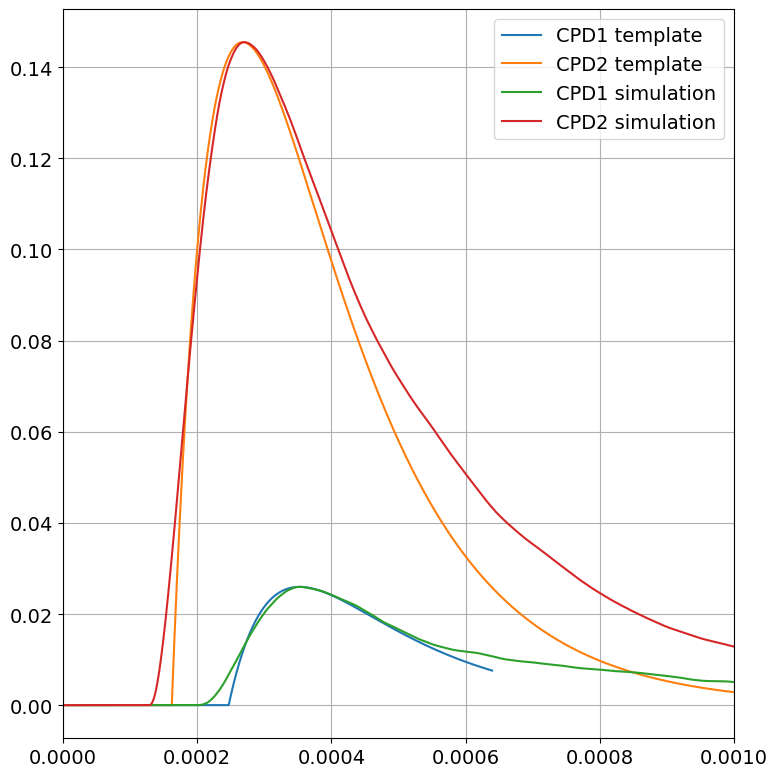

In [11]:
fig, ax = plt.subplots(1, 1, figsize = (8,8), sharex=True, sharey=True)
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_normalized_template.npy')
template_1 = template[2]
template_2 = template[3]


with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_33.pkl', 'rb') as file:
    evap = pickle.load(file)
s1, s2 , time =generate_waveform(evap)
peak_1 = np.max(s1)
peak_index_signal_1 = np.argmax(s1)
peak_index_template_1 = np.argmax(template_1)
diff = peak_index_signal_1 - peak_index_template_1
before_pad = int(diff)
after_pad = len(s1) - len(template_1) -before_pad
new_template_1 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_1

peak_2 = np.max(s2)
peak_index_signal_2 = np.argmax(s2)
peak_index_template_2 = np.argmax(template_2)
diff = peak_index_signal_2 - peak_index_template_2
before_pad = int(diff)
after_pad = len(s1) - len(template_1) -before_pad
new_template_2 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_2




ax.plot(time[:1600], new_template_1[:1600], label = 'CPD1 template')
ax.plot(time, new_template_2, label = 'CPD2 template')
ax.plot(time, s1, label='CPD1 simulation')
ax.set_xlim(0, 0.001)
ax.plot(time, s2, label='CPD2 simulation')
ax.legend()
ax.grid()
fig.tight_layout()

1.0000000022644964


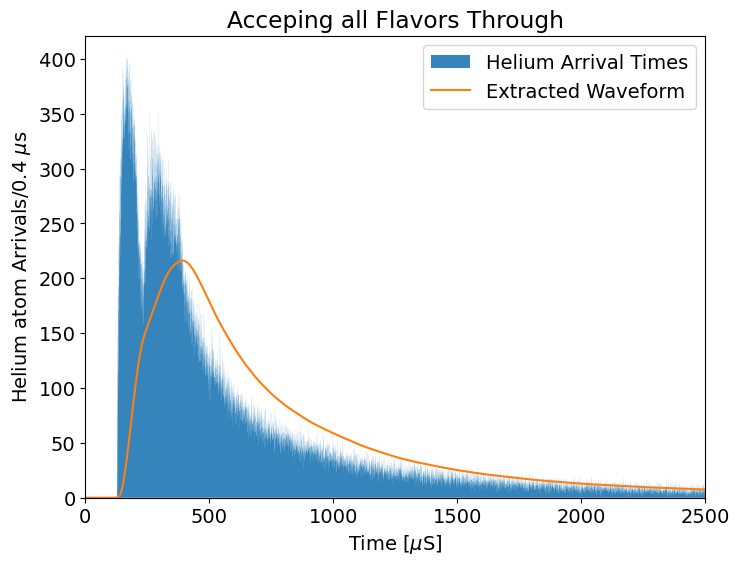

In [28]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/talk_plots/accept_all_through.pkl', 'rb') as f:
    evap = pickle.load(f)

fs = np.concatenate((evap.flavor[0], evap.flavor[1]))
total_arrival_times = np.concatenate((evap.arrivalTimes_us[0], evap.arrivalTimes_us[1]))



fig, ax = plt.subplots(1,1, figsize =(8, 6))

hits, bins, something = ax.hist(total_arrival_times, bins = 12500, range = [0,5000], alpha= 0.9,stacked=True,histtype='stepfilled', label = 'Helium Arrival Times')
ax.set_title(f'Acceping all Flavors Through')
ax.legend()
ax.set_xlabel(r"Time [$\mu$S]" )
ax.set_ylabel(r"Helium atom Arrivals/0.4 $\mu$s" )
# now I need to convolve my waveform with this: can do that by the 

template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_normalized_template.npy')
template_1 = template[0]
signal_1 = np.convolve(hits, template_1)
print(np.sum(0.4 * template_1))
time = np.arange(0, (len(template_1) + len(hits) -1) * 0.4e-6, 0.4e-6) * 1e6

ax.plot(time , signal_1 *hits_sum/signal_sum , label = 'Extracted Waveform')
ax.legend()
ax.set_xlim(0, 2500)

fig.savefig("./data/plots/example_waveform.png", dpi=200)

In [17]:
5000/0.4

12500.0

In [24]:
signal_sum = (np.sum(0.4 * signal_1))
hits_sum = (np.sum(0.4* hits))

[0.4 0.4 0.4 ... 0.4 0.4 0.4]


In [24]:
template_time = np.arange(0, len(template_1)*0.4e-6, 0.4e-6)
print(np.sum(np.diff(template_time) * template_1[:-1]))


2.115688946381594e-06


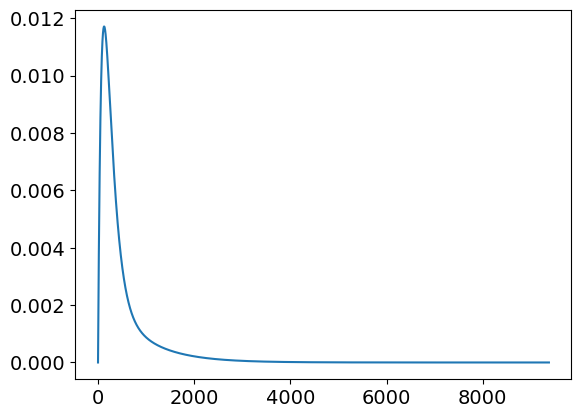

In [ ]:
plt.plot(template_1)

In [7]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/testing/arrival_time_vs_momentum_2.pkl', 'rb') as f:
    evap = pickle.load(f)
print(np.shape(evap.momentum[1]))
print(np.shape(evap.arrivalTimes_us[1]))

(7950,)
(7950,)


(0.0, 1000.0)

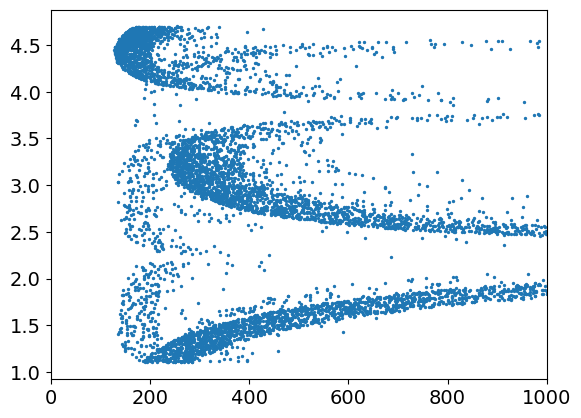

In [9]:
plt.scatter(evap.arrivalTimes_us[0], evap.momentum[0], s = 2)
plt.xlim(0,1000)

Text(0.5, 0.98, 'Analyzing Arrival Times based on Initial Momentum')

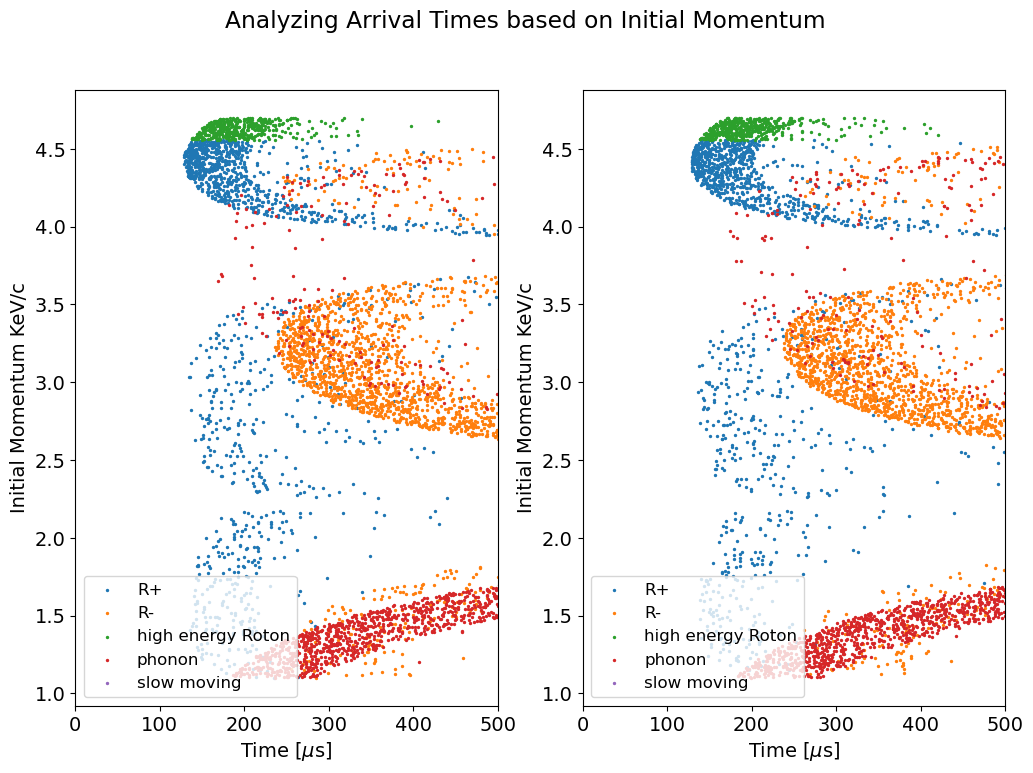

In [23]:
fig, axs = plt.subplots(1, 2, figsize = (12,8))

for i in range(2):
    # sweep over plots
    for value in np.unique(evap.flavor[i]):
        # sweep over flavors
        mask = (value == evap.flavor[i])
        axs[i].scatter(evap.arrivalTimes_us[i][mask], evap.momentum[i][mask], s=2, label= value)
        axs[i].set_xlim(0, 500)
    axs[i].set_xlabel(r'Time [$\mu$s]')
    axs[i].set_ylabel('Initial Momentum KeV/c')
    axs[i].legend(loc='lower left', fontsize=12)
fig.suptitle('Analyzing Arrival Times based on Initial Momentum')

(8316,)
(8316,)


Text(0.5, 0.98, 'Analyzing Arrival Times based on Initial Momentum')

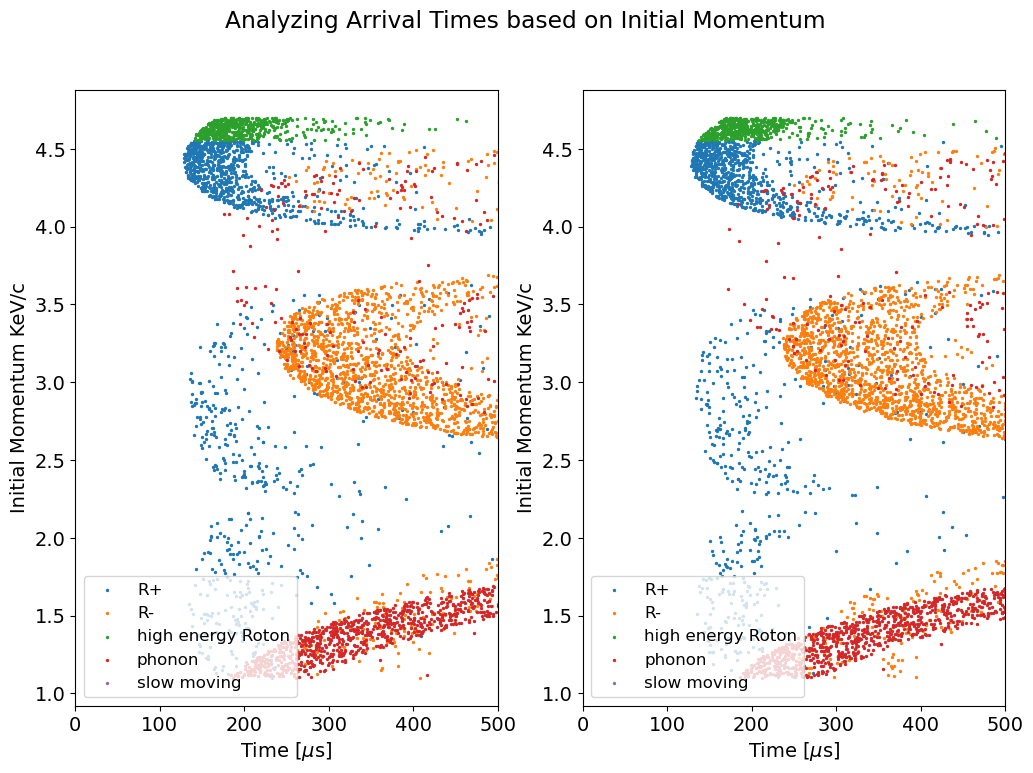

In [5]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/testing/height_5_mm.pkl', 'rb') as f:
    evap = pickle.load(f)
print(np.shape(evap.momentum[1]))
print(np.shape(evap.arrivalTimes_us[1]))


fig, axs = plt.subplots(1, 2, figsize = (12,8))

for i in range(2):
    # sweep over plots
    for value in np.unique(evap.flavor[i]):
        # sweep over flavors
        mask = (value == evap.flavor[i])
        axs[i].scatter(evap.arrivalTimes_us[i][mask], evap.momentum[i][mask], s=2, label= value)
        axs[i].set_xlim(0, 500)
    axs[i].set_xlabel(r'Time [$\mu$s]')
    axs[i].set_ylabel('Initial Momentum KeV/c')
    axs[i].legend(loc='lower left', fontsize=12)
fig.suptitle('Analyzing Arrival Times based on Initial Momentum')

(8890,)
(8890,)


Text(0.5, 0.98, 'Analyzing Arrival Times based on Initial Momentum')

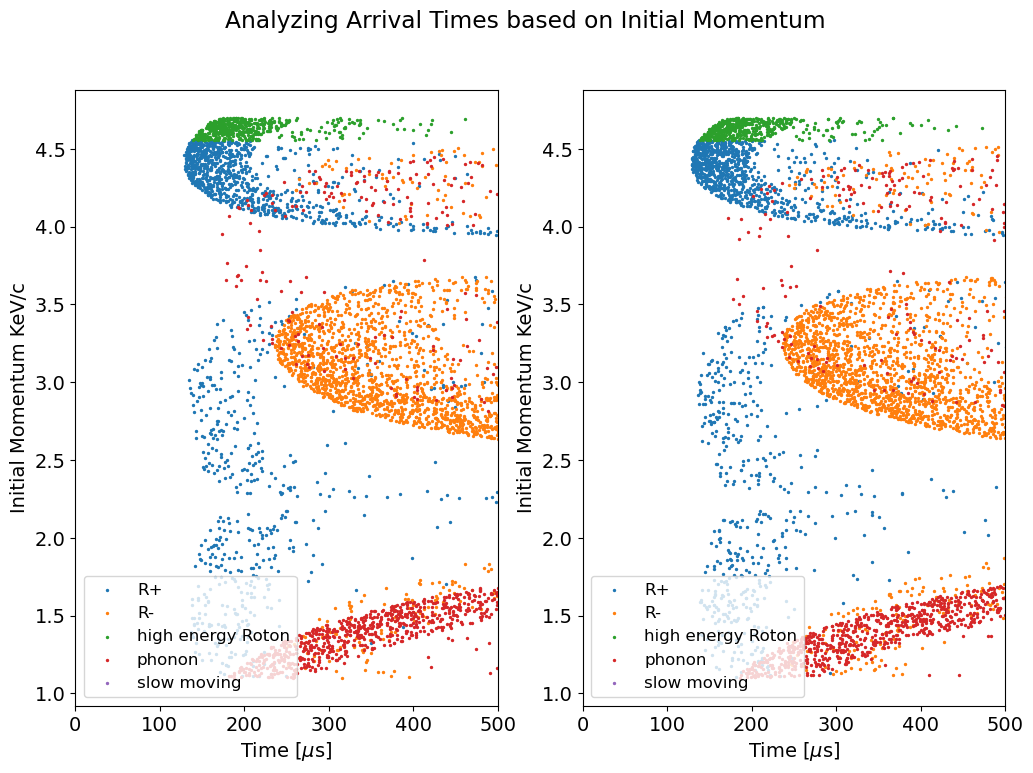

In [6]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/testing/height_5_mm.pkl', 'rb') as f:
    evap = pickle.load(f)
print(np.shape(evap.momentum[1]))
print(np.shape(evap.arrivalTimes_us[1]))


fig, axs = plt.subplots(1, 2, figsize = (12,8))

for i in range(2):
    # sweep over plots
    for value in np.unique(evap.flavor[i]):
        # sweep over flavors
        mask = (value == evap.flavor[i])
        axs[i].scatter(evap.arrivalTimes_us[i][mask], evap.momentum[i][mask], s=2, label= value)
        axs[i].set_xlim(0, 500)
    axs[i].set_xlabel(r'Time [$\mu$s]')
    axs[i].set_ylabel('Initial Momentum KeV/c')
    axs[i].legend(loc='lower left', fontsize=12)
fig.suptitle('Analyzing Arrival Times based on Initial Momentum')

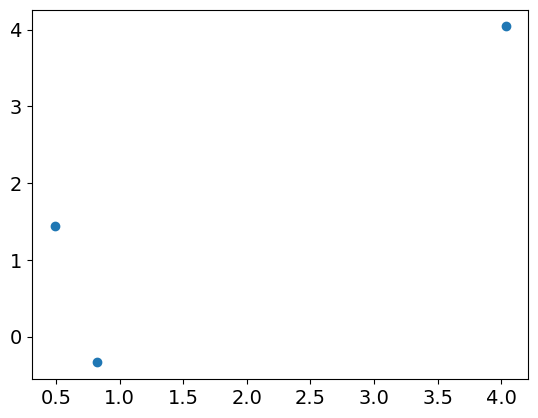

In [31]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/testing/experimental_optimization_runs.pkl', 'rb') as f:
    evap = pickle.load(f)


# plot_hist_flavors(evap)


plt.scatter(evap.positions[0], evap.positions[1])